# EDA — Diabetes 130-US Hospitals (1999–2008)

**Project question:** Given what is known about a diabetic patient's hospital stay, can we predict whether they will be **readmitted within 30 days**? If so, hospitals could target follow-up calls, medication reviews, or discharge planning at the highest-risk patients.

**Input:** `data/diabetic_data_clean.csv` - pre-EDA cleaning file (output of `cleaning_amy.ipynb`)

**Output:** decision table (Section 12) and `data/diabetic_data_model.csv`, a model-ready file built from those decisions (Section 13).

**Notebook layout** (follows the EDA stages: structure → univariate → bivariate → multivariate → decisions):
* **Sections 1–3:** setup, the target variable, and repeat patients
* **Sections 4–5:** univariate analysis (numeric and categorical)
* **Sections 6–8:** bivariate analysis
* **Section 9:** multivariate analysis
* **Section 10:** medication columns
* **Sections 11–13:** key findings, decision table, the model-ready file, and next steps

**Figures:** Saved as PNG in `figures/`.

# Part B — Exploratory Data Analysis

## 1. Setup & load

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)

# Chart style: Times New Roman, light grid, no top/right borders
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#e5e5e5'
plt.rcParams['axes.axisbelow'] = True

# Colorblind-safe colors
BLUE = '#0072B2'
ORANGE = '#D55E00'
GREEN = '#009E73'
GRAY = '#808080'

# Folder for chart images
os.makedirs('../figures', exist_ok=True)

In [2]:
# Load the clean file.
str_cols = ['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']
df_all = pd.read_csv("../data/diabetic_data_clean.csv", dtype={c: str for c in str_cols}, low_memory=False)

# Binary target: 1 = readmitted within 30 days, 0 = '>30' or 'NO'
df_all['readmitted_30'] = (df_all['readmitted'] == '<30').astype(int)

print(df_all.shape)

(99320, 53)


## 2. The target: readmitted

The target has three classes. 

Our question is only about <30, so >30 and NO are combined into class 0.


In [3]:
# Count and percent of each class
counts = df_all['readmitted'].value_counts()[['NO', '>30', '<30']]
percent = counts / len(df_all) * 100
print(pd.DataFrame({'n': counts, 'percent': percent.round(1)}))

                n  percent
readmitted                
NO          52513     52.9
>30         35498     35.7
<30         11309     11.4


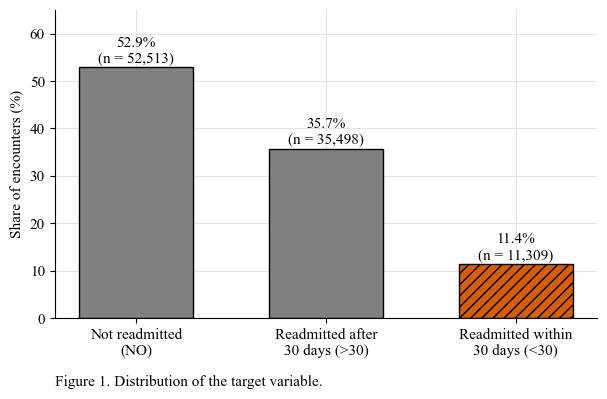

In [4]:
# Figure 1: bar chart of the target variable

labels = ['Not readmitted\n(NO)', 'Readmitted after\n30 days (>30)', 'Readmitted within\n30 days (<30)']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, percent, color=[GRAY, GRAY, ORANGE], edgecolor='black', width=0.6)
bars[2].set_hatch('///')

# Data labels on top of each bar
for bar, p, n in zip(bars, percent, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, p + 1, f'{p:.1f}%\n(n = {n:,})', ha='center')

ax.set_ylabel('Share of encounters (%)')
ax.set_ylim(0, 65)

# Caption and save
fig.text(0.125, -0.06, 'Figure 1. Distribution of the target variable.', ha='left')
plt.savefig('../figures/fig01_target.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
*  Only **11.4%** of encounters are readmitted within 30 days → the classes are **imbalanced (about 1 : 8)**.
* A model that always predicts "not readmitted" would be 88.6% accurate and completely useless, so **accuracy is the wrong metric**.
* We will use **PR-AUC, recall, precision and F1** (and ROC-AUC for comparison). The no-skill PR-AUC equals the positive rate.
* `>30` readmissions are common (35.7%) but outside our question, so they become class 0.

Notes:

*PR-AUC (Precision-Recall Area Under the Curve): shows how well the model finds the readmitted patients. 

*ROC-AUC (Receiver Operating Characteristic, Area Under the Curve): shows how well the model ranks readmitted patients above the others.

*Recall: the share of readmitted patients that the model finds.

*Precision: the share of the model's alerts that are correct.

*F1: one score that combines recall and precision.

## 3. Repeat patients

Some patients have many hospital visits in the data. If the same patient is in both, the train set and the test set, the model can memorise the patient, and the results look better than they really are. This is called **data leakage**.

In [5]:
# Encounters per patient
visits = df_all['patient_nbr'].value_counts()
print("Encounters:", len(df_all))
print("Unique patients:", len(visits))
print("Patients with more than 1 encounter:", (visits > 1).sum())
print("Max encounters for one patient:", visits.max())

Encounters: 99320
Unique patients: 69979
Patients with more than 1 encounter: 16335
Max encounters for one patient: 40


In [6]:
# Number each patient's encounters in time order (encounter_id grows with time)
df_all = df_all.sort_values('encounter_id').reset_index(drop=True)
df_all['encounter_number'] = df_all.groupby('patient_nbr').cumcount() + 1

# Readmission rate (%) and number of encounters for the 1st, 2nd, 3rd and 4th-or-later encounter
order = df_all['encounter_number'].clip(upper=4)
by_order = df_all.groupby(order)['readmitted_30'].agg(rate='mean', n='size')
by_order['rate'] = (by_order['rate'] * 100).round(1)

# Used in Figure 2
rate_by_order = by_order['rate']

by_order

,rate,n
encounter_number,,
1,9.0,69979
2,14.2,16335
3,17.4,6120
4,23.9,6886


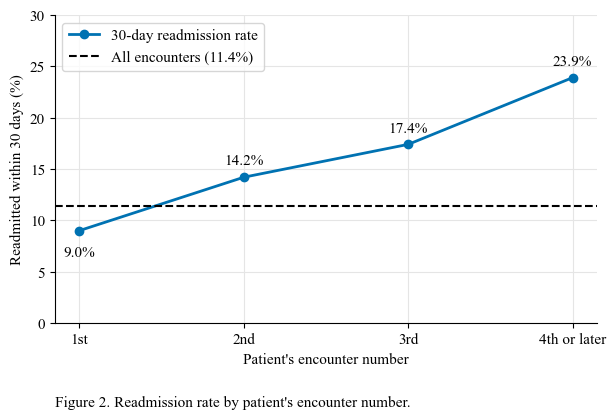

In [7]:
# Figure 2: readmission rate by patient's encounter number

x = ['1st', '2nd', '3rd', '4th or later']
overall_all = df_all['readmitted_30'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, rate_by_order, color=BLUE, marker='o', linewidth=2, label='30-day readmission rate')

# Reference line: all encounters
ax.axhline(overall_all, color='black', linestyle='--', label=f'All encounters ({overall_all:.1f}%)')

# Data labels
for i in range(4):
    if i == 0:
        y = rate_by_order.iloc[i] - 2.5
    else:
        y = rate_by_order.iloc[i] + 1.2
    ax.text(i, y, f'{rate_by_order.iloc[i]:.1f}%', ha='center')

ax.set_xlabel("Patient's encounter number")
ax.set_ylabel('Readmitted within 30 days (%)')
ax.set_ylim(0, 30)
ax.legend(loc='upper left')

# Caption and save
fig.text(0.125, -0.1, "Figure 2. Readmission rate by patient's encounter number.", ha='left')
plt.savefig('../figures/fig02_repeat_patients.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* 99,320 encounters belong to only 69,979 patients. About **1 in 4 patients comes back** more than once.
* The readmission rate rises steeply with each repeat encounter: **9.0%** for a first encounter vs. **23.9%** for the fourth or later. Repeat encounters come from sicker patients, and many rows (up to 40) describe the same person, so the rows are not separate cases.
* **Decision:** keep **one encounter per patient (the first one)**. This removes leakage between train and test sets and gives every patient equal weight. It is the approach used in the original study of this dataset (Strack et al., 2014).
* From here on, all analysis uses this one-encounter-per-patient table, so the EDA looks at exactly the rows the model will see.

In [8]:
# Keep the first encounter of each patient
df = df_all.drop_duplicates('patient_nbr', keep='first').reset_index(drop=True)

# Overall rate, used as a reference line in the charts below
overall = df['readmitted_30'].mean() * 100
print("Rows:", len(df))
print(f"Readmission rate: {overall:.1f}%")

Rows: 69979
Readmission rate: 9.0%


* After keeping one encounter per patient the positive class is **9.0%** (about 1 : 10), slightly more imbalanced than before. The no-skill PR-AUC baseline for the model is therefore about **0.09**.

## 4. Univariate analysis — numeric features

What shape does each numeric feature have? 

Skewed counts may need a transform for logistic regression.

In [9]:
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

# Summary statistics and skew
summary = df[numeric_cols].describe().T[['mean', '50%', 'min', 'max']]
summary['skew'] = df[numeric_cols].skew()
summary.round(2)

,mean,50%,min,max,skew
time_in_hospital,4.27,3.0,1.0,14.0,1.18
num_lab_procedures,42.88,44.0,1.0,132.0,-0.22
num_procedures,1.43,1.0,0.0,6.0,1.23
num_medications,15.67,14.0,1.0,81.0,1.43
number_outpatient,0.28,0.0,0.0,42.0,9.70
number_emergency,0.10,0.0,0.0,42.0,21.23
number_inpatient,0.18,0.0,0.0,12.0,5.59
number_diagnoses,7.22,8.0,1.0,16.0,-0.73


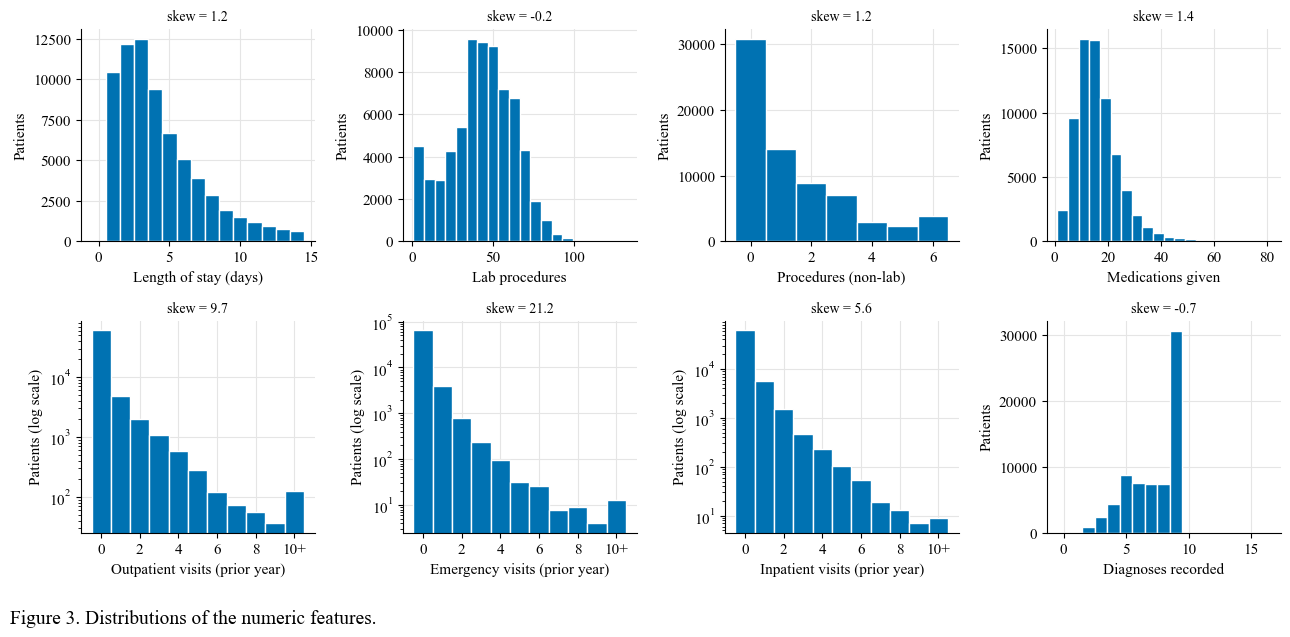

In [10]:
# Figure 3: histograms of the numeric features

# Axis names for the charts
names = {
    'time_in_hospital': 'Length of stay (days)',
    'num_lab_procedures': 'Lab procedures',
    'num_procedures': 'Procedures (non-lab)',
    'num_medications': 'Medications given',
    'number_outpatient': 'Outpatient visits (prior year)',
    'number_emergency': 'Emergency visits (prior year)',
    'number_inpatient': 'Inpatient visits (prior year)',
    'number_diagnoses': 'Diagnoses recorded',
}
visit_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']

# One histogram per numeric column
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, col in zip(axes.flat, numeric_cols):
    if col in visit_cols:
        # Mostly zeros: cut at 10 and use a log scale
        ax.hist(df[col].clip(upper=10), bins=range(12), align='left', color=BLUE, edgecolor='white')
        ax.set_yscale('log')
        ax.set_ylabel('Patients (log scale)')
        ax.set_xticks([0, 2, 4, 6, 8, 10], ['0', '2', '4', '6', '8', '10+'])
    elif df[col].max() <= 20:
        # Small whole numbers: one bar per value
        ax.hist(df[col], bins=range(df[col].max() + 2), align='left', color=BLUE, edgecolor='white')
        ax.set_ylabel('Patients')
    else:
        ax.hist(df[col], bins=20, color=BLUE, edgecolor='white')
        ax.set_ylabel('Patients')
    ax.set_xlabel(names[col])
    ax.set_title(f'skew = {df[col].skew():.1f}', fontsize=10)
plt.tight_layout()

# Caption and save
fig.text(0.01, -0.05, 'Figure 3. Distributions of the numeric features.', ha='left', fontsize=14)
plt.savefig('../figures/fig03_numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* `time_in_hospital`, `num_lab_procedures`, `num_medications` and `number_diagnoses` have reasonable shapes and plausible ranges (no impossible values).
* The prior-visit counts (`number_outpatient`, `number_emergency`, `number_inpatient`) are **heavily right-skewed**: most patients have zero visits and a few have very many. These are real values, not entry errors, so we **keep them** (no outlier removal).
* For logistic regression a `log1p` transform (or capping) of the three visit counts will help; tree models do not need it.
* `number_diagnoses` has a spike at 9, which is likely a recording limit in the source hospitals' systems.

## 5. Univariate analysis — categorical features

How many categories does each column have, and how dominant is the most common one? 

Very rare categories are hard to use in a model.

In [11]:
cat_cols = ['race', 'gender', 'age', 'admission_type', 'discharge_disposition', 'admission_source',
            'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']

# Summary of each categorical column
rows = []
for col in cat_cols:
    shares = df[col].value_counts(normalize=True) * 100
    rows.append({
        'column': col,
        'n_categories': df[col].nunique(),
        'most_common': shares.index[0],
        'pct_most_common': round(shares.iloc[0], 1),
        'pct_missing': round(df[col].isna().mean() * 100, 1),
        'n_rare (<1%)': (shares < 1).sum(),
    })
pd.DataFrame(rows).set_index('column')

,n_categories,most_common,pct_most_common,pct_missing,n_rare (<1%)
column,,,,,
race,6,Caucasian,74.7,0.0,1
gender,2,Female,53.2,0.0,0
age,10,[70-80),25.4,0.0,2
admission_type,6,Emergency,50.7,0.0,2
discharge_disposition,20,Discharged to home,63.3,0.0,13
admission_source,15,Emergency Room,53.3,0.0,9
payer_code,17,MC,50.0,43.5,7
medical_specialty,67,InternalMedicine,29.3,48.1,51
max_glu_serum,4,Not measured,95.2,0.0,0


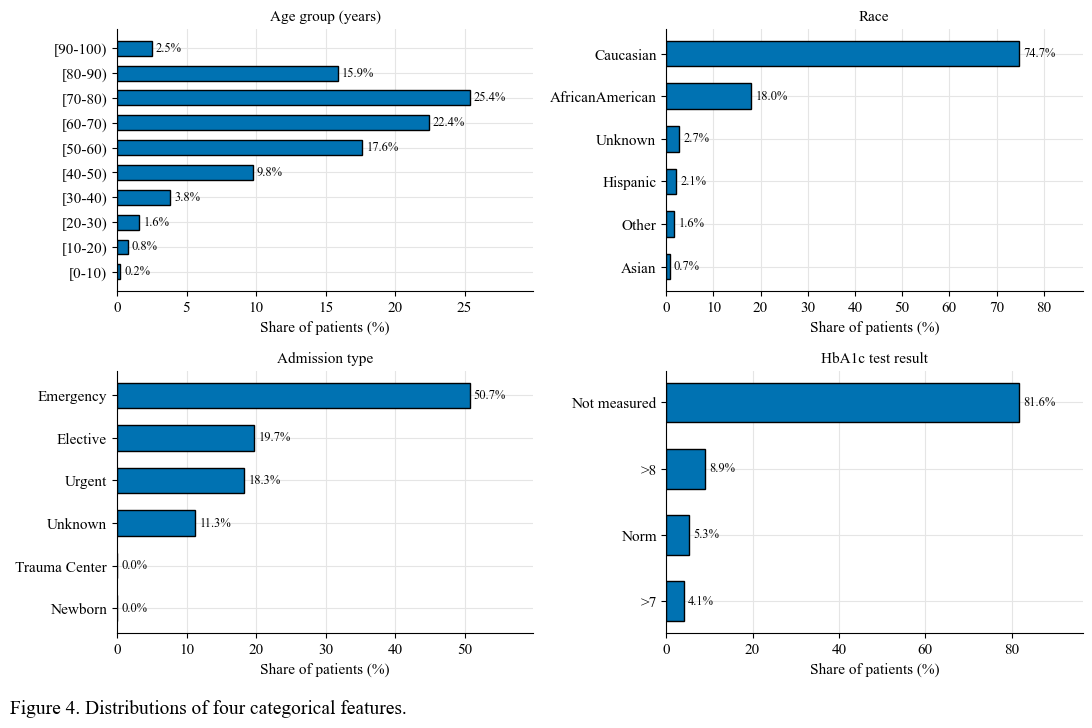

In [12]:
# Figure 4: bar charts of four categorical features

plot_cols = ['age', 'race', 'admission_type', 'A1Cresult']
titles = ['Age group (years)', 'Race', 'Admission type', 'HbA1c test result']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, title in zip(axes.flat, plot_cols, titles):
    # Share of patients in each category (%)
    shares = df[col].value_counts(normalize=True) * 100
    if col == 'age':
        shares = shares.sort_index()    # age groups stay in their natural order
    else:
        shares = shares.sort_values()   # other columns: sorted by size
    bars = ax.barh(shares.index, shares, color=BLUE, edgecolor='black', height=0.6)

    # Data labels at the end of each bar
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Share of patients (%)')
    ax.set_xlim(0, shares.max() * 1.18)
plt.tight_layout()

# Caption and save
fig.text(0.01, -0.03, 'Figure 4. Distributions of four categorical features.', ha='left', fontsize=14)
plt.savefig('../figures/fig04_categorical.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* Figure 4: most patients are older (`age` 50–90, 81%), Caucasian (75%), and admitted through emergency (51%).
* `A1Cresult` is "Not measured" for 82% of patients, and `max_glu_serum` for 95% — this is a real category (the test was not ordered), not missing data.
* Some categories are almost empty (e.g. Trauma Center and Newborn, < 0.1% of patients).
* `discharge_disposition`, `admission_source`, `payer_code` and `medical_specialty` also have **many rare categories (< 1% of rows)**. These will be grouped into `Other` so the model does not learn from a handful of patients.
* `payer_code` and `medical_specialty` are still ~44% and ~48% missing (Section 8 decides what to do with them).

## 6. Bivariate analysis — numeric features vs. 30-day readmission

Which numeric features move with readmission? 

First the prior-visit counts, then the features of the current stay.

In [13]:
def rate_by(col, data=None):
    # Readmission rate (%) and number of patients for each value of col
    data = df if data is None else data
    t = data.groupby(col, observed=True)['readmitted_30'].agg(rate='mean', n='size')
    t['rate'] = (t['rate'] * 100).round(1)
    return t

visit_rates ={col: rate_by(df[col].clip(upper=4).rename(col)) for col in visit_cols}   # 4 = four or more visits
pd.concat(visit_rates, axis=1)

number_outpatient        number_emergency        number_inpatient       
               rate      n             rate      n             rate      n
0               8.8  60857              8.7  64879              8.1  61783
1              10.4   4780             11.2   3882             12.9   5800
2              10.3   1982             13.4    789             18.5   1501
3               8.7   1096             12.8    242             23.6    462
4              10.7   1264             20.9    187             29.3    433

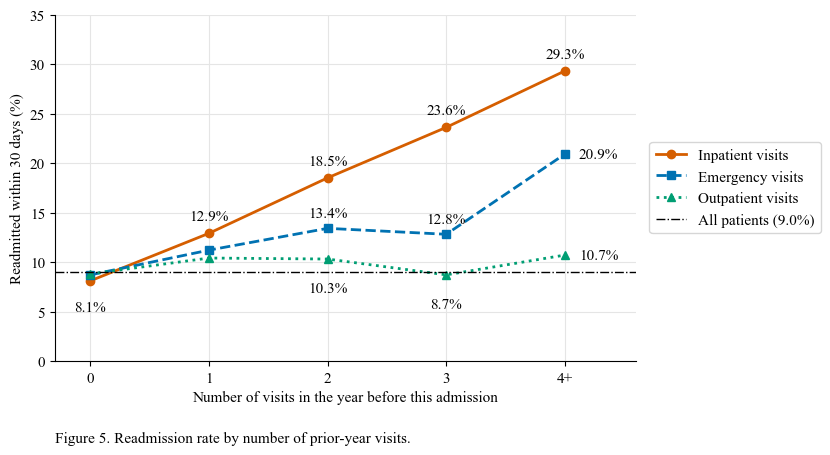

In [14]:
# Figure 5: readmission rate by number of prior-year visits

# Readmission rate by number of prior visits (4 = four or more)
inpatient = rate_by(df['number_inpatient'].clip(upper=4))
emergency = rate_by(df['number_emergency'].clip(upper=4))
outpatient = rate_by(df['number_outpatient'].clip(upper=4))

x = ['0', '1', '2', '3', '4+']

# Each line has its own color, line style and marker
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(x, inpatient['rate'], color=ORANGE, linestyle='-', marker='o', linewidth=2, label='Inpatient visits')
ax.plot(x, emergency['rate'], color=BLUE, linestyle='--', marker='s', linewidth=2, label='Emergency visits')
ax.plot(x, outpatient['rate'], color=GREEN, linestyle=':', marker='^', linewidth=2, label='Outpatient visits')

# Reference line: all patients
ax.axhline(overall, color='black', linestyle='-.', linewidth=1, label=f'All patients ({overall:.1f}%)')

# Data labels: every point of the inpatient line (the main result)
for i in range(5):
    if i == 0:
        y = inpatient['rate'].iloc[i] - 3   # first label below the point, where the three lines meet
    else:
        y = inpatient['rate'].iloc[i] + 1.3
    ax.text(i, y, f"{inpatient['rate'].iloc[i]:.1f}%", ha='center')

# Data labels: last three points of the other two lines (the first points are too close together)
for i in [2, 3]:
    ax.text(i, emergency['rate'].iloc[i] + 1.1, f"{emergency['rate'].iloc[i]:.1f}%", ha='center')    # above the point
    ax.text(i, outpatient['rate'].iloc[i] - 3.3, f"{outpatient['rate'].iloc[i]:.1f}%", ha='center')   # below the point
ax.text(4.12, emergency['rate'].iloc[4], f"{emergency['rate'].iloc[4]:.1f}%", va='center')
ax.text(4.12, outpatient['rate'].iloc[4], f"{outpatient['rate'].iloc[4]:.1f}%", va='center')

ax.set_xlabel('Number of visits in the year before this admission')
ax.set_ylabel('Readmitted within 30 days (%)')
ax.set_ylim(0, 35)
ax.set_xlim(-0.3, 4.6)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))  # legend outside the chart

# Caption and save
fig.text(0.125, -0.07, 'Figure 5. Readmission rate by number of prior-year visits.', ha='left')
plt.savefig('../figures/fig05_prior_visits.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* **Prior inpatient visits are the strongest signal found so far**: the rate rises steadily from **8.1%** with no prior stays to **29.3%** with four or more. That is more than 3 times the overall rate.
* Emergency visits show a weaker, less regular upward trend (8.7% → 20.9%); outpatient visits stay close to the overall rate (8.7–10.7%).
* Group sizes shrink fast (most patients have 0 visits), so the rates for 3 and 4+ visits rest on a few hundred patients.

In [15]:
stay_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses']

readmitted = df[df['readmitted_30'] == 1]
not_readmitted = df[df['readmitted_30'] == 0]

# Compare the two groups: medians and Mann-Whitney U test (works for skewed data)
rows = []
for col in stay_cols:
    p_value = stats.mannwhitneyu(readmitted[col], not_readmitted[col]).pvalue
    rows.append({'feature': col,
                 'median_readmitted': readmitted[col].median(),
                 'median_not_readmitted': not_readmitted[col].median(),
                 'p_value': p_value})
pd.DataFrame(rows).set_index('feature')

,median_readmitted,median_not_readmitted,p_value
feature,,,
time_in_hospital,4.0,3.0,4.456898e-56
num_lab_procedures,46.0,44.0,8.966594e-18
num_medications,15.0,14.0,2.750057e-29
number_diagnoses,8.0,8.0,2.874146e-30


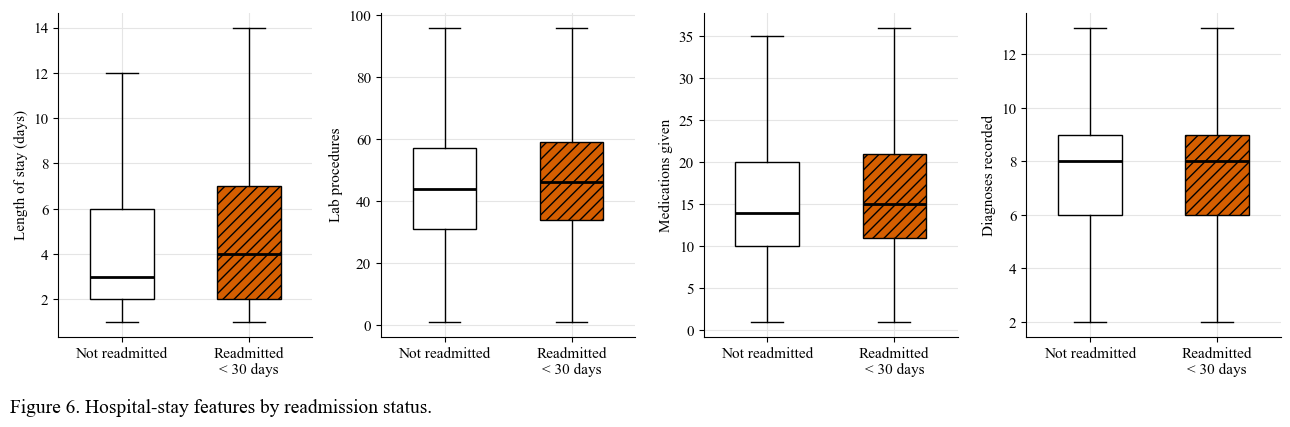

In [16]:
# Figure 6: box plots of hospital-stay features by readmission status

# One box plot per stay feature (outliers hidden)
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, col in zip(axes, stay_cols):
    box = ax.boxplot([not_readmitted[col], readmitted[col]], widths=0.5, patch_artist=True, showfliers=False,
                     medianprops={'color': 'black', 'linewidth': 2})

    # Readmitted group: orange with hatch
    box['boxes'][0].set_facecolor('white')
    box['boxes'][1].set_facecolor(ORANGE)
    box['boxes'][1].set_hatch('///')

    ax.set_xticks([1, 2], ['Not readmitted', 'Readmitted\n< 30 days'])
    ax.set_ylabel(names[col])
plt.tight_layout()

# Caption and save
fig.text(0.01, -0.05, 'Figure 6. Hospital-stay features by readmission status.', ha='left', fontsize=14)
plt.savefig('../figures/fig06_stay_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* Readmitted patients have **slightly longer stays** and **slightly more medications, lab procedures and diagnoses**. All differences are statistically significant (p < 0.001), but that is mostly because the sample is large.
* The boxes overlap almost completely, so **no single stay feature separates the two classes** on its own. This explains why readmission is hard to predict.

## 7. Bivariate analysis — categorical features vs. 30-day readmission

For categories we compare **rates**, not counts, and we always show the group size. A high rate in a group of 20 patients does not mean much.

### 7.1 Age

In [17]:
age_rates = rate_by('age')
age_rates

,rate,n
age,,
[0-10),2.0,153
[10-20),4.9,534
[20-30),7.4,1121
[30-40),7.0,2692
[40-50),7.4,6826
[50-60),7.1,12351
[60-70),9.0,15684
[70-80),10.2,17749
[80-90),10.8,11108


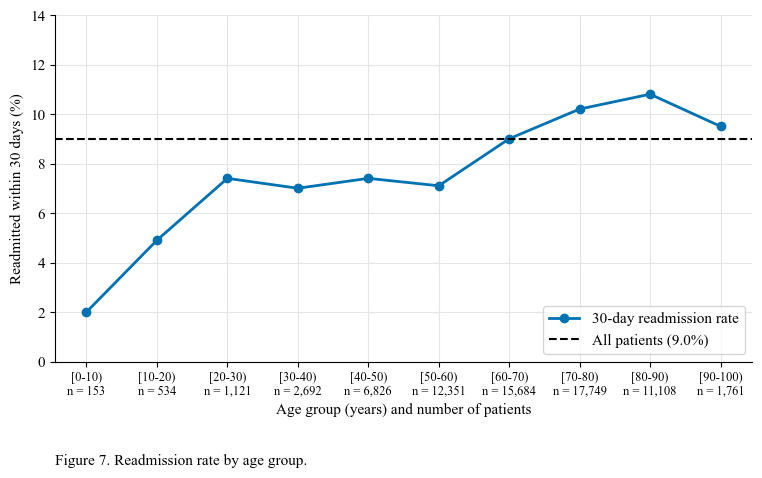

In [18]:
# Figure 7: readmission rate by age group

# X labels: age group + number of patients
x_labels = [f'{age}\nn = {n:,}' for age, n in zip(age_rates.index, age_rates['n'])]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_labels, age_rates['rate'], color=BLUE, marker='o', linewidth=2, label='30-day readmission rate')

# Reference line: all patients
ax.axhline(overall, color='black', linestyle='--', label=f'All patients ({overall:.1f}%)')

ax.set_xlabel('Age group (years) and number of patients')
ax.set_ylabel('Readmitted within 30 days (%)')
ax.set_ylim(0, 14)
ax.tick_params(axis='x', labelsize=9)
ax.legend(loc='lower right')

# Caption and save
fig.text(0.125, -0.12, 'Figure 7. Readmission rate by age group.', ha='left')
plt.savefig('../figures/fig07_age.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* The readmission rate **increases with age**: about 7% from 20 to 60 years, then 9.0% at 60-70 and 10.2 - 10.8% for patients aged 70-90.
* Patients under 20 are very few (less than 700) and are rarely readmitted (2-5%).
* The age brackets are ordered, so for the model we can turn them into one number (e.g. `[70-80)` → 75). 

### 7.2 Discharge disposition

Where the patient goes after discharge is known at discharge time, so it is a valid predictor (no leakage).

In [19]:
# Readmission rate by discharge destination (groups with at least 300 patients)
dis = rate_by('discharge_disposition')
dis = dis[dis['n'] >= 300]
dis = dis.sort_values('rate')

# Shorter labels for the chart
dis = dis.rename(index={
    'Discharged to home': 'Home',
    'Discharged/transferred to home with home health service': 'Home with home health service',
    'Discharged/transferred to SNF': 'Skilled nursing facility (SNF)',
    'Discharged/transferred to ICF': 'Intermediate care facility (ICF)',
    'Discharged/transferred to another short term hospital': 'Another short-term hospital',
    'Discharged/transferred to another rehab fac including rehab units of a hospital .': 'Rehab facility',
    'Discharged/transferred to another type of inpatient care institution': 'Other inpatient care',
    'Left AMA': 'Left against medical advice',
})
dis

,rate,n
discharge_disposition,,
Home,6.9,44318
Unknown,9.2,3251
Home with home health service,9.5,8290
Left against medical advice,9.6,408
Intermediate care facility (ICF),10.3,542
Skilled nursing facility (SNF),13.4,8788
Another short-term hospital,13.7,1540
Other inpatient care,20.6,913
Rehab facility,26.4,1410


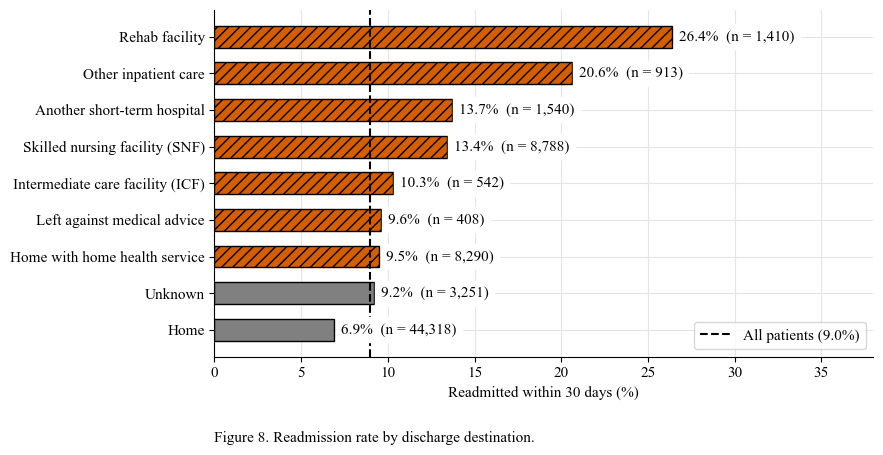

In [20]:
# Figure 8: readmission rate by discharge destination

# Groups more than 0.5 points above the overall rate: orange with hatch
colors = [ORANGE if rate > overall + 0.5 else GRAY for rate in dis['rate']]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.barh(dis.index, dis['rate'], color=colors, edgecolor='black', height=0.6)
for bar, color in zip(bars, colors):
    if color == ORANGE:
        bar.set_hatch('///')

# Reference line: all patients
ax.axvline(overall, color='black', linestyle='--', label=f'All patients ({overall:.1f}%)')

# Data labels at the end of each bar
for bar, rate, n in zip(bars, dis['rate'], dis['n']):
    ax.text(rate + 0.4, bar.get_y() + bar.get_height() / 2, f'{rate:.1f}%  (n = {n:,})', va='center',
            backgroundcolor='white')

ax.set_xlabel('Readmitted within 30 days (%)')
ax.set_xlim(0, 38)
ax.legend(loc='lower right')

# Caption and save
fig.text(0.125, -0.08, 'Figure 8. Readmission rate by discharge destination.', ha='left')
plt.savefig('../figures/fig08_discharge.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* Discharge destination shows **one of the widest spreads of any feature**: from about 7% for patients sent home to about 26% for patients sent to a rehab facility.
* Transfers to skilled nursing (SNF), other inpatient care, and other short-term hospitals are all well above average, these patients are sicker or need more care.
* `Unknown` sits close to the overall rate. Categories with fewer than 1% of patients will be grouped into `Other`.

### 7.3 Primary diagnosis

`diag_1` has hundreds of raw ICD-9 codes, too many to use directly. We group them into the nine disease categories used in the original study of this dataset (Strack et al., 2014).

In [21]:
# Map an ICD-9 code to a disease group (ranges from Strack et al., 2014)
def icd9_group(code):
    if pd.isna(code):
        return 'None'   # no 2nd / 3rd diagnosis
    if code.startswith('V') or code.startswith('E'):
        return 'Other'  # supplementary codes
    value = float(code)
    if 390 <= value < 460 or int(value) == 785:
        return 'Circulatory'
    if 460 <= value < 520 or int(value) == 786:
        return 'Respiratory'
    if 520 <= value < 580 or int(value) == 787:
        return 'Digestive'
    if int(value) == 250:
        return 'Diabetes'
    if 800 <= value < 1000:
        return 'Injury'
    if 710 <= value < 740:
        return 'Musculoskeletal'
    if 580 <= value < 630 or int(value) == 788:
        return 'Genitourinary'
    if 140 <= value < 240:
        return 'Neoplasms'
    return 'Other'

df['diag_1_group'] = df['diag_1'].apply(icd9_group)
print("Codes in diag_1:", df['diag_1'].nunique(), "→ groups:", df['diag_1_group'].nunique())

diag_rates = rate_by('diag_1_group').sort_values('rate')
diag_rates

Codes in diag_1: 694 → groups: 9


,rate,n
diag_1_group,,
Respiratory,7.3,9491
Digestive,8.0,6488
Musculoskeletal,8.4,4064
Other,9.0,12124
Genitourinary,9.0,3441
Neoplasms,9.1,2538
Diabetes,9.1,5748
Circulatory,9.7,21391
Injury,10.8,4694


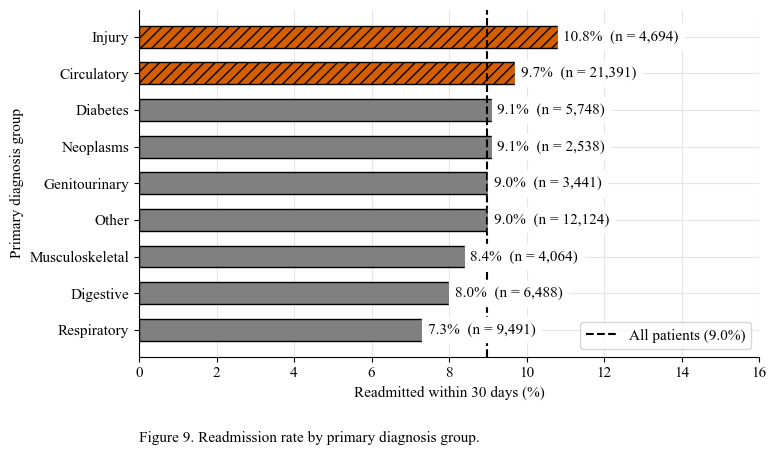

In [22]:
# Figure 9: readmission rate by primary diagnosis group

# Groups more than 0.5 points above the overall rate: orange with hatch
colors = [ORANGE if rate > overall + 0.5 else GRAY for rate in diag_rates['rate']]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(diag_rates.index, diag_rates['rate'], color=colors, edgecolor='black', height=0.6)
for bar, color in zip(bars, colors):
    if color == ORANGE:
        bar.set_hatch('///')

# Reference line: all patients
ax.axvline(overall, color='black', linestyle='--', label=f'All patients ({overall:.1f}%)')

# Data labels at the end of each bar
for bar, rate, n in zip(bars, diag_rates['rate'], diag_rates['n']):
    ax.text(rate + 0.15, bar.get_y() + bar.get_height() / 2, f'{rate:.1f}%  (n = {n:,})', va='center',
            backgroundcolor='white')

ax.set_xlabel('Readmitted within 30 days (%)')
ax.set_ylabel('Primary diagnosis group')
ax.set_xlim(0, 16)
ax.legend(loc='lower right')

# Caption and save
fig.text(0.125, -0.08, 'Figure 9. Readmission rate by primary diagnosis group.', ha='left')
plt.savefig('../figures/fig09_diagnosis.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* Circulatory diseases are by far the most common primary diagnosis (21,391 patients).
* Rates differ between groups, from **7.3%** (respiratory) to **10.8%** (injury). This difference is small compared with prior visits or discharge destination.
* Grouping turns about 700 codes into 9 clear categories, which is what we will use for the model.

### 7.4 HbA1c test and change of diabetes medication

The original study of this dataset asked whether **measuring HbA1c** (a long-term blood sugar test) is linked to readmission. Here we look at the test result together with whether the diabetes medication was changed during the stay.

In [23]:
# Readmission rate by HbA1c result and medication change (Ch = changed, No = not changed)
a1c_order = ['Not measured', 'Norm', '>7', '>8']
a1c = df.groupby(['A1Cresult', 'change'])['readmitted_30'].mean().unstack() * 100
a1c = a1c.loc[a1c_order]
a1c.round(1)

change,Ch,No
A1Cresult,,
Not measured,9.7,8.7
Norm,8.6,8.6
>7,8.8,8.4
>8,8.6,7.4


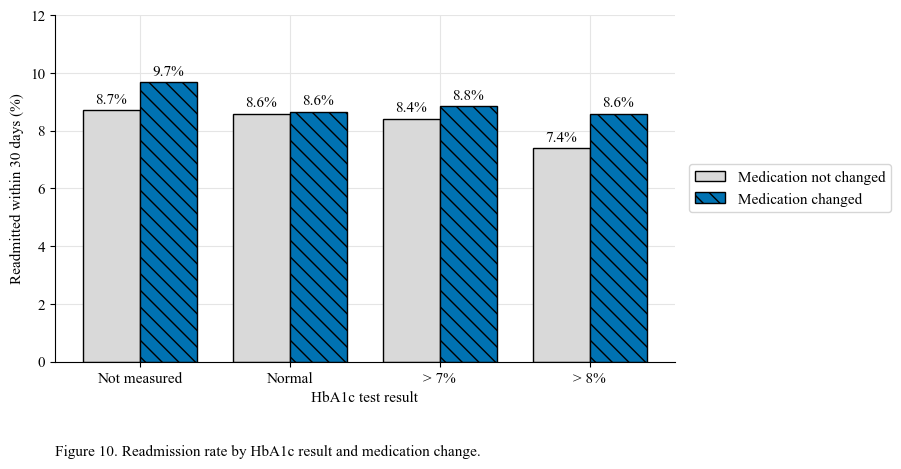

In [24]:
# Figure 10: readmission rate by HbA1c result and medication change

x = np.arange(4)
width = 0.38

# Grouped bars: light gray = not changed, blue with hatch = changed
fig, ax = plt.subplots(figsize=(8, 4.5))
bars_no = ax.bar(x - width / 2, a1c['No'], width, color='#D9D9D9', edgecolor='black', label='Medication not changed')
bars_ch = ax.bar(x + width / 2, a1c['Ch'], width, color=BLUE, edgecolor='black', hatch='\\\\', label='Medication changed')

# Data labels on top of each bar
ax.bar_label(bars_no, fmt='%.1f%%', padding=3)
ax.bar_label(bars_ch, fmt='%.1f%%', padding=3)

ax.set_xticks(x, ['Not measured', 'Normal', '> 7%', '> 8%'])
ax.set_xlabel('HbA1c test result')
ax.set_ylabel('Readmitted within 30 days (%)')
ax.set_ylim(0, 12)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))  # legend outside the chart

# Caption and save
fig.text(0.125, -0.1, 'Figure 10. Readmission rate by HbA1c result and medication change.', ha='left')
plt.savefig('../figures/fig10_a1c_change.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* About **82% of patients never had HbA1c measured**; together with a medication change, this group has the highest rate (9.7%). "Not measured" is kept as its own category.
* Within every test group, a medication **change** goes with an equal or higher readmission rate (largest gap for `>8`: 8.6% vs. 7.4%).
* Both effects are small (mostly under 1 percentage point), and the chi-square test in Section 7.5 finds no significant link for `A1Cresult` alone (p ≈ 0.06). These features may help the model a little but are weak on their own.

### 7.5 Which categorical features are linked to readmission?

A chi-square test checks whether the readmission rate differs between categories. Because the sample is large, even tiny differences become "significant", so we also report **Cramér's V** (effect size: 0 = no relationship, 1 = perfect).

In [25]:
# Chi-square test and Cramér's V for each categorical column vs. the target
rows = []
for col in cat_cols + ['diag_1_group', 'insulin']:
    table = pd.crosstab(df[col].fillna('Missing'), df['readmitted_30'])
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    cramers_v = np.sqrt(chi2 / len(df))  # formula for a 2-class target
    rows.append({'feature': col, 'p_value': p_value, 'cramers_v': round(cramers_v, 3)})

pd.DataFrame(rows).set_index('feature').sort_values('cramers_v', ascending=False)

,p_value,cramers_v
feature,,
discharge_disposition,9.037034e-268,0.137
medical_specialty,1.717102e-15,0.054
age,5.325142e-36,0.052
payer_code,4.768201e-20,0.044
diag_1_group,8.774450e-13,0.032
diabetesMed,2.788532e-13,0.028
insulin,8.846337e-11,0.027
race,2.265593e-03,0.016
admission_source,3.280220e-01,0.015


#### Observations
* `discharge_disposition` has by far the strongest association (Cramér's V = 0.14), followed by `medical_specialty`, `age`, `payer_code` and `diag_1_group` (V ≈ 0.03–0.05).
* `gender`, `A1Cresult`, `max_glu_serum` and `admission_source` are **not significant** (p > 0.05); `race`, `change` and `admission_type` are significant but tiny.
* Apart from discharge destination, every effect size is below 0.06. No single feature explains readmission; a model has to combine many weak signals.
* Weak features are still kept for now: tree models can ignore them, and model-based feature importance will confirm which ones matter.

## 8. Decision on `payer_code` and `medical_specialty`

The cleaning notebook left these two columns as NaN until EDA could answer: **is the column useful, and is the missingness itself informative?**

In [26]:
for col in ['payer_code', 'medical_specialty']:
    is_missing = df[col].isna().map({True: 'Missing', False: 'Recorded'}).rename(col + ' is')
    print(rate_by(is_missing), '\n')

               rate      n
payer_code is             
Missing         9.9  30410
Recorded        8.3  39569 

                      rate      n
medical_specialty is             
Missing                9.2  33661
Recorded               8.7  36318 



In [27]:
rate_by('medical_specialty').query('n >= 500').sort_values('rate', ascending=False)

,rate,n
medical_specialty,,
Psychiatry,11.1,613
Nephrology,11.0,797
Orthopedics,9.9,1128
InternalMedicine,9.8,10641
Family/GeneralPractice,9.7,4978
Pulmonology,9.4,637
Surgery-General,8.3,2206
Emergency/Trauma,7.8,4392
Urology,7.6,526


#### Observations
* Patients with a **missing** `payer_code` are readmitted more often (9.9% vs. 8.3%); for `medical_specialty` the gap is smaller (9.2% vs. 8.7%). Missingness carries some information, and dropping the rows would lose 44–48% of the data.
* Among recorded specialties the rate ranges from 3.7% (obstetrics) to 11.1% (psychiatry), and Section 7.5 ranks `medical_specialty` second among categorical features.
* **Decision:** keep both columns. Fill missing values with `Unknown`, and group rare categories into `Other`(`medical_specialty`: keep the 10 most common specialties; `payer_code`: keep codes with ≥ 1% of patients).

## 9. Multivariate analysis

### 9.1 Correlation between numeric features

Are any numeric features so strongly related that they carry the same information? 

Spearman correlation is used because the features are skewed counts.

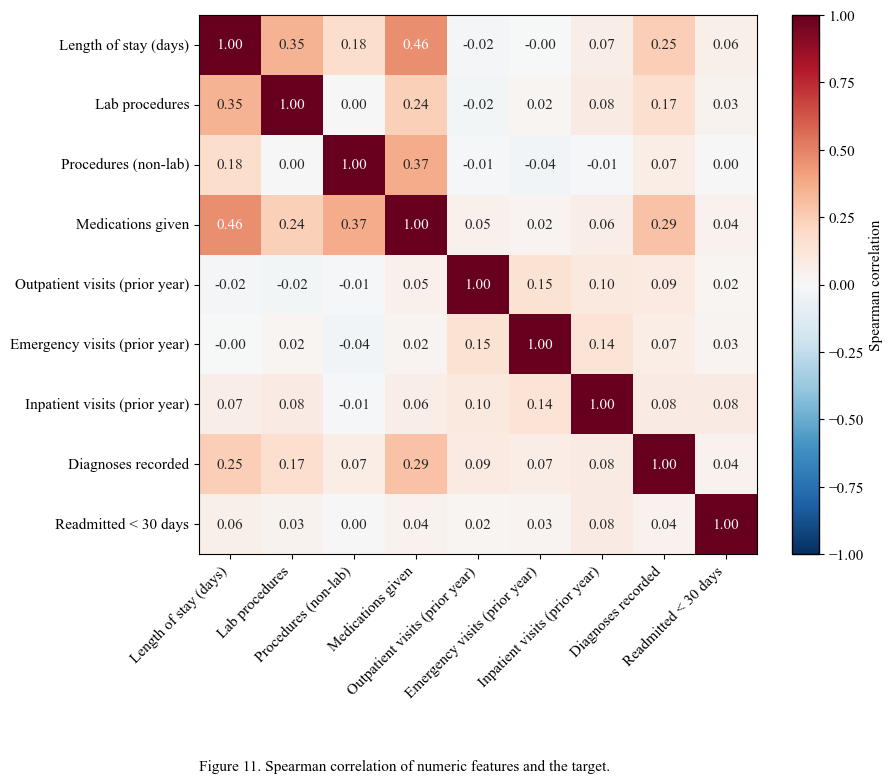

In [28]:
# Figure 11: correlation heatmap of numeric features and the target

# Spearman correlation (better than Pearson for skewed data)
corr = df[numeric_cols + ['readmitted_30']].corr(method='spearman')
corr_labels = list(names.values()) + ['Readmitted < 30 days']

# Heatmap with the number in every cell
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=corr_labels, yticklabels=corr_labels, cbar_kws={'label': 'Spearman correlation'}, ax=ax)
plt.xticks(rotation=45, ha='right')

# Black frame around the heatmap and the color bar
for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_visible(True)
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

# Caption and save
fig.text(0.125, -0.2, 'Figure 11. Spearman correlation of numeric features and the target.', ha='left')
plt.savefig('../figures/fig11_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* The strongest pairs are `num_medications` with `time_in_hospital` (0.46) and with `num_procedures` (0.37). Longer and more complex stays need more medications.
* **No pair is high enough to be redundant**, so all eight numeric features are kept.
* Every correlation with the target is weak (≤ 0.08); `number_inpatient` is the largest, matching Figure 5.

### 9.2 Is the prior-visit effect the same in every age group?

Older patients have more hospital stays, so the age effect (Figure 7) and the prior-visit effect (Figure 5) could be the same thing.

To check, we look at prior visits **inside each age group**.

In [29]:
# 5 age bands and 4 visit bands (3+ = three or more)
age_band = df['age'].map({
    '[0-10)': 'Under 50', '[10-20)': 'Under 50', '[20-30)': 'Under 50', '[30-40)': 'Under 50', '[40-50)': 'Under 50',
    '[50-60)': '50–59', '[60-70)': '60–69', '[70-80)': '70–79', '[80-90)': '80+', '[90-100)': '80+',
})
visit_band = df['number_inpatient'].clip(upper=3).astype(str).replace('3', '3+')

# Readmission rate and group size for each age band x visit band
rates = df.groupby([age_band, visit_band])['readmitted_30'].mean().unstack() * 100
sizes = df.groupby([age_band, visit_band]).size().unstack()
rates = rates.loc[['Under 50', '50–59', '60–69', '70–79', '80+']]
sizes = sizes.loc[rates.index]
rates.round(1)

number_inpatient,0,1,2,3+
age,,,,
Under 50,6.2,12.3,14.8,28.8
50–59,6.4,10.7,17.0,22.1
60–69,8.2,12.8,17.5,28.4
70–79,9.4,14.0,20.3,22.6
80+,9.7,13.5,20.9,30.6


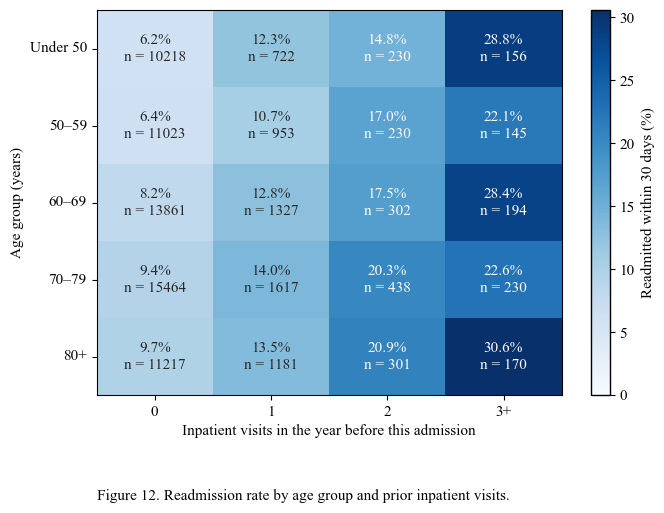

In [30]:
# Figure 12: heatmap of readmission rate by age group and prior inpatient visits

# Cell text: rate and number of patients
cell_text = rates.round(1).astype(str) + '%\nn = ' + sizes.astype(str)

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.heatmap(rates, annot=cell_text, fmt='', cmap='Blues', vmin=0,
            cbar_kws={'label': 'Readmitted within 30 days (%)'}, ax=ax)
ax.set_xlabel('Inpatient visits in the year before this admission')
ax.set_ylabel('Age group (years)')
plt.yticks(rotation=0)

# Black frame around the heatmap and the color bar
for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_visible(True)
cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)

# Caption and save
fig.text(0.125, -0.1, 'Figure 12. Readmission rate by age group and prior inpatient visits.', ha='left')
plt.savefig('../figures/fig12_age_and_visits.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* In **every age group** the readmission rate climbs steadily from 0 to 3+ prior inpatient visits (e.g. 70–79: 9.4% → 22.6%). So prior inpatient visits are **a real risk signal on their own**, not just a sign of older age.
* With the same number of visits, older patients still have a slightly higher rate. We need both features in the model.
* The 3+ column has only 145–230 patients per age group, so these numbers are less exact.

## 10. Medication columns

There are 23 medication columns. Each one shows if the drug was given and if the dose went `Up`, `Down`, or stayed `Steady`.

In [31]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
            'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
            'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# % of patients who got each drug (any value except 'No')
med_use = (df[med_cols] != 'No').mean() * 100
med_use.sort_values(ascending=False).round(2)

insulin                     51.04
metformin                   21.29
glipizide                   12.87
glyburide                   11.11
pioglitazone                 7.52
rosiglitazone                6.65
glimepiride                  5.28
repaglinide                  1.31
glyburide-metformin          0.71
nateglinide                  0.70
acarbose                     0.29
chlorpropamide               0.10
tolazamide                   0.04
miglitol                     0.03
tolbutamide                  0.02
glipizide-metformin          0.01
troglitazone                 0.00
metformin-rosiglitazone      0.00
acetohexamide                0.00
metformin-pioglitazone       0.00
citoglipton                  0.00
examide                      0.00
glimepiride-pioglitazone     0.00
dtype: float64

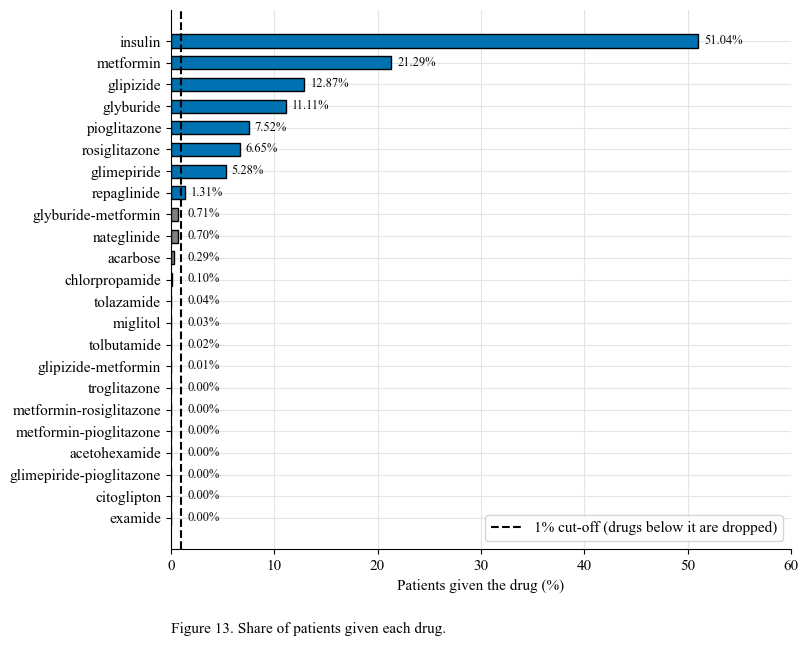

In [32]:
# Figure 13: share of patients given each drug, with the 1% cut-off

use = med_use.sort_values()

# Drugs kept (at least 1% of patients): blue. Drugs dropped: gray
colors = [BLUE if share >= 1 else GRAY for share in use]

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(use.index, use, color=colors, edgecolor='black', height=0.6)

# Cut-off line: drugs below 1% are dropped
ax.axvline(1, color='black', linestyle='--', label='1% cut-off (drugs below it are dropped)')

# Data labels (for very short bars the label starts after the cut-off line)
for bar, share in zip(bars, use):
    ax.text(max(share, 1) + 0.6, bar.get_y() + bar.get_height() / 2, f'{share:.2f}%', va='center', fontsize=9)

ax.set_xlabel('Patients given the drug (%)')
ax.set_xlim(0, 60)
ax.legend(loc='lower right')

# Caption and save
fig.text(0.125, -0.01, 'Figure 13. Share of patients given each drug.', ha='left')
plt.savefig('../figures/fig13_drug_use.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
rate_by('insulin')

,rate,n
insulin,,
Down,10.5,7323
No,8.3,34261
Steady,9.3,21619
Up,9.8,6776


#### Observations
* Only **8 drugs** are given to at least 1% of patients. The other 15 are almost always `No` (`examide` and `citoglipton` are never given).
  They have almost no information → **drop them**.
* For insulin, patients with a dose change (`Up` 9.8%, `Down` 10.5%) are readmitted more often than patients with no insulin (8.3%).
  A dose change can mean unstable blood sugar. So we add one new feature: `num_med_changes` = how many drugs had a dose change.

## 11. Key findings

**What we learned about 30-day readmission**
1. The target is **imbalanced**: 9.0% positive after keeping one encounter per patient (Figure 1, Section 3).
2. **Repeat patients cause data leakage** and are readmitted more often; we keep the first encounter per patient (Figure 2).
3. **Prior inpatient visits** are the strongest single predictor, and the effect holds within every age group (Figures 5 and 12).
4. **Discharge destination** strongly separates risk: rehab, other inpatient care, and nursing facilities are far above patients sent home (Figure 8).
5. Age, medical specialty, primary diagnosis group, HbA1c testing and medication changes each add **small** differences (Figures 7, 9, 10; Section 7.5).
6. Features of the current stay overlap a lot between the classes (Figure 6), and all correlations with the target are weak (Figure 11). 

Overall, **readmission is driven by many weak signals**, so we should not expect a very accurate model.

These findings are the basis for the ML direction.

## 12. Summary of EDA decisions

| # | Column / issue | Finding | Evidence | Decision |
|---|---|---|---|---|
| 1 | `readmitted` (target) | 3 classes; our question is "within 30 days"; 11.4% positive rate | Section 2, Fig. 1 | New binary target `readmitted_30` (1 = `<30`, 0 = `>30` or `NO`); drop the 3-class column to avoid leakage |
| 2 | Repeat patients (`patient_nbr`) | 69,979 patients for 99,320 encounters; later encounters much riskier | Section 3, Fig. 2 | Keep the **first encounter per patient** (69,979 rows); positive rate becomes 9.0% |
| 3 | Class imbalance | ~1 : 10 after deduplication | Section 3 | Stratified split, class weights, PR-AUC as the main metric (handled in modelling) |
| 4 | Prior-visit counts | Heavily right-skewed, but real values | Section 4, Fig. 3 | Keep raw values (no outlier removal); apply `log1p` only for logistic regression in the modelling pipeline |
| 5 | `age` | Ordered brackets; rate rises with age | Section 7.1, Fig. 7 | Convert to numeric `age_num` = bracket midpoint (e.g. `[70-80)` → 75) |
| 6 | `diag_1`, `diag_2`, `diag_3` | Hundreds of raw ICD-9 codes each (694 in `diag_1`) | Section 7.3, Fig. 9 | Group into 9 disease categories (`diag_*_group`); missing `diag_2`/`diag_3` → `None`; drop raw codes |
| 7 | `payer_code` | ~44% missing; missing group readmitted more often (9.9% vs. 8.3%) | Section 8 | Fill with `Unknown`; group codes with < 1% of patients into `Other` |
| 8 | `medical_specialty` | ~48% missing; second-strongest categorical feature | Sections 7.5 & 8 | Fill with `Unknown`; keep the 10 most common specialties, the rest → `Other` |
| 9 | `discharge_disposition`, `admission_source`, `admission_type` | Many rare categories | Sections 5 & 7.2, Fig. 4 & 8 | Group categories with < 1% of patients into `Other`; keep the description columns, drop the `*_id` code columns |
| 10 | `A1Cresult`, `max_glu_serum` | "Not measured" is the largest group (82% and 95% of patients) | Sections 5 & 7.4, Fig. 4 & 10 | Keep as categorical, with "Not measured" as its own category |
| 11 | Medication columns | 15 of 23 drugs used by < 1% of patients; dose changes linked to risk | Section 10 | Drop the 15 rare drugs; add `num_med_changes` (number of drugs with dose `Up` or `Down`) |
| 12 | `change`, `diabetesMed` | Yes/No style text | Section 7.4 | Convert to 0/1 |
| 13 | ID columns | `encounter_id`, `patient_nbr`, `encounter_number` are not features | Section 3 | Drop after deduplication |
| 14 | Numeric features | No redundant pairs (largest \|ρ\| = 0.46) | Section 9.1, Fig. 11 | Keep all 8 numeric features |

## 13. Apply the decisions and save the model-ready file

Applies the decision table to the one-encounter-per-patient data and saves `data/diabetic_data_model.csv` for modelling (Python or RAPIDS).

In [34]:
model = df.copy()

# Row 11: number of drugs with a dose change (counted before dropping the rare drugs)
model['num_med_changes'] = (model[med_cols] == 'Up').sum(axis=1) + (model[med_cols] == 'Down').sum(axis=1)

# Row 6: disease groups for the 3 diagnosis columns
model['diag_1_group'] = model['diag_1'].apply(icd9_group)
model['diag_2_group'] = model['diag_2'].apply(icd9_group)
model['diag_3_group'] = model['diag_3'].apply(icd9_group)

# Row 5: age group -> middle of the group, e.g. '[70-80)' -> 75
model['age_num'] = model['age'].str[1:].str.split('-').str[0].astype(int) + 5

# Row 12: text -> 0/1
model['change'] = (model['change'] == 'Ch').astype(int)
model['diabetesMed'] = (model['diabetesMed'] == 'Yes').astype(int)

# Rows 7-8: missing -> 'Unknown'
model['payer_code'] = model['payer_code'].fillna('Unknown')
model['medical_specialty'] = model['medical_specialty'].fillna('Unknown')

# Keep the categories in `keep` and 'Unknown'; the rest become 'Other'
def group_rare(column, keep):
    return column.where(column.isin(keep) | (column == 'Unknown'), 'Other')

# Row 8: keep the 10 most common specialties
top10 = model['medical_specialty'][model['medical_specialty'] != 'Unknown'].value_counts().index[:10]
model['medical_specialty'] = group_rare(model['medical_specialty'], top10)

# Rows 7 and 9: keep categories with at least 1% of patients
for col in ['payer_code', 'discharge_disposition', 'admission_source', 'admission_type']:
    shares = model[col].value_counts(normalize=True)
    model[col] = group_rare(model[col], shares[shares >= 0.01].index)

# Rows 1, 6, 9, 11, 13: drop columns we do not need anymore
rare_meds = med_use[med_use < 1].index.tolist()
drop_cols = ['readmitted', 'encounter_id', 'patient_nbr', 'encounter_number', 'age',
             'diag_1', 'diag_2', 'diag_3',
             'admission_type_id', 'discharge_disposition_id', 'admission_source_id'] + rare_meds
model = model.drop(columns=drop_cols)

print("Dropped rare medications:", rare_meds)
print(model.shape)

Dropped rare medications: ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
(69979, 33)


### Checks

In [35]:
print("One row per patient:", len(model) == 69_979)
print("No missing values:", model.isna().sum().sum() == 0)
print("Old 3-class target removed:", 'readmitted' not in model.columns)
print(f"Readmission rate: {model['readmitted_30'].mean() * 100:.1f}%")
model.head()

One row per patient: True
No missing values: True
Old 3-class target removed: True
Readmission rate: 9.0%


,race,gender,admission_type,discharge_disposition,admission_source,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted_30,diag_1_group,num_med_changes,diag_2_group,diag_3_group,age_num
0,Caucasian,Female,Urgent,Discharged to home,Transfer from a hospital,13,Unknown,Unknown,68,2,28,0,0,0,8,Not measured,Not measured,No,No,No,Steady,No,No,No,Steady,1,1,0,Circulatory,0,Circulatory,Other,85
1,Caucasian,Female,Elective,Discharged/transferred to SNF,Transfer from a hospital,12,Unknown,InternalMedicine,33,3,18,0,0,0,8,Not measured,Not measured,No,No,No,No,No,No,Steady,Steady,1,1,0,Circulatory,0,Neoplasms,Respiratory,95
2,Caucasian,Male,Emergency,Discharged to home,Emergency Room,1,Unknown,Unknown,51,0,8,0,0,0,5,Not measured,Not measured,No,No,No,Steady,No,No,No,Steady,1,1,0,Neoplasms,0,Neoplasms,Diabetes,45
3,AfricanAmerican,Female,Emergency,Discharged to home,Emergency Room,9,Unknown,Unknown,47,2,17,0,0,0,9,Not measured,Not measured,No,No,No,No,No,No,No,Steady,0,1,0,Diabetes,0,Circulatory,Injury,45
4,Caucasian,Male,Urgent,Discharged to home,Clinic Referral,3,Unknown,Unknown,31,6,16,0,0,0,9,Not measured,Not measured,No,No,No,No,No,No,No,Steady,0,1,0,Circulatory,0,Circulatory,Diabetes,55


In [36]:
model.to_csv("../data/diabetic_data_model.csv", index=False)
print("Saved", model.shape)

Saved (69979, 33)


### Before and after the transformations

Two charts show what the main transformations change: grouping the ICD-9 codes (row 6) and `log1p` on the visit counts (row 4).

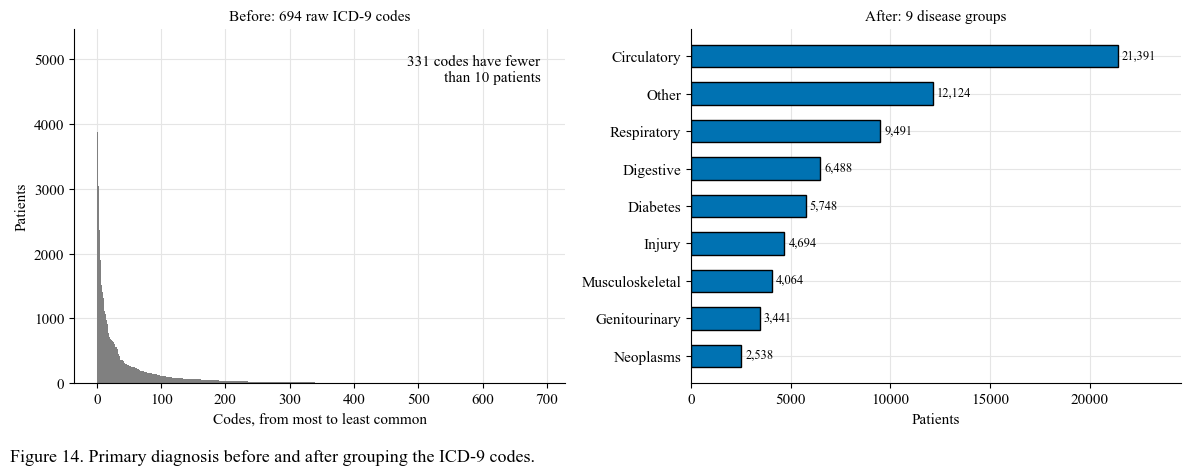

In [37]:
# Figure 14: primary diagnosis before and after grouping

code_counts = df['diag_1'].value_counts()                      # raw codes, most common first
group_counts = df['diag_1_group'].value_counts().sort_values() # 9 groups
rare_codes = (code_counts < 10).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Before: one bar per raw code (long tail of rare codes)
axes[0].bar(range(len(code_counts)), code_counts.values, color=GRAY, width=1)
axes[0].set_title(f'Before: {len(code_counts)} raw ICD-9 codes', fontsize=11)
axes[0].set_xlabel('Codes, from most to least common')
axes[0].set_ylabel('Patients')
axes[0].text(0.95, 0.85, f'{rare_codes} codes have fewer\nthan 10 patients', transform=axes[0].transAxes, ha='right')

# After: one bar per disease group
bars = axes[1].barh(group_counts.index, group_counts.values, color=BLUE, edgecolor='black', height=0.6)
axes[1].bar_label(bars, labels=[f'{n:,}' for n in group_counts.values], padding=3, fontsize=9)
axes[1].set_title('After: 9 disease groups', fontsize=11)
axes[1].set_xlabel('Patients')
axes[1].set_xlim(0, group_counts.max() * 1.15)
plt.tight_layout()

# Caption and save
fig.text(0.01, -0.04, 'Figure 14. Primary diagnosis before and after grouping the ICD-9 codes.', ha='left', fontsize=13)
plt.savefig('../figures/fig14_diagnosis_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* Before grouping, `diag_1` has 694 different codes, and 331 of them (48%) have fewer than 10 patients. Most codes are too rare for a model to learn from.
* After grouping there are 9 groups, and each one has at least 2,500 patients.

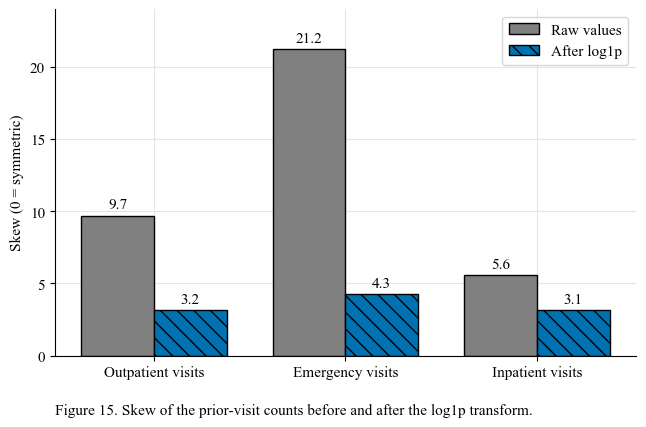

In [38]:
# Figure 15: skew of the visit counts before and after the log1p transform

skew_raw = df[visit_cols].skew()
skew_log = np.log1p(df[visit_cols]).skew()   # log1p(x) = log(1 + x), works for zero

x = np.arange(3)
width = 0.38

# Grouped bars: gray = raw values, blue with hatch = after log1p
fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars_raw = ax.bar(x - width / 2, skew_raw, width, color=GRAY, edgecolor='black', label='Raw values')
bars_log = ax.bar(x + width / 2, skew_log, width, color=BLUE, edgecolor='black', hatch='\\\\', label='After log1p')

# Data labels on top of each bar
ax.bar_label(bars_raw, fmt='%.1f', padding=3)
ax.bar_label(bars_log, fmt='%.1f', padding=3)

ax.set_xticks(x, ['Outpatient visits', 'Emergency visits', 'Inpatient visits'])
ax.set_ylabel('Skew (0 = symmetric)')
ax.set_ylim(0, 24)
ax.legend(loc='upper right')

# Caption and save
fig.text(0.125, -0.02, 'Figure 15. Skew of the prior-visit counts before and after the log1p transform.', ha='left')
plt.savefig('../figures/fig15_log1p_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

#### Observations
* `log1p` reduces the skew of all three visit counts: outpatient 9.7 → 3.2, emergency 21.2 → 4.3, inpatient 5.6 → 3.1.
* The features are still skewed after the transform, because most patients have zero visits and no transform can change that.
* `log1p` is only needed for logistic regression, so it is applied in the modelling pipeline. The model file keeps the raw counts.

### Notes for ML and RAPIDS

**What the file contains:** `data/diabetic_data_model.csv` has 69,979 patients (first encounter only), 1 binary target (`readmitted_30`, 9.0% positive),
numeric features, and categorical features with `Unknown` / `Other` instead of missing or rare values.

**Loading the model file:** all columns load with the right types, no special `dtype` arguments are needed:
```python
df = pd.read_csv("../data/diabetic_data_model.csv")
X = df.drop(columns='readmitted_30')
y = df['readmitted_30']
```

**For ML (still to do in the modelling pipeline, fit on the training set only):**
* One-hot encode the categorical columns (or use native categorical support in LightGBM / XGBoost).
* For logistic regression: `log1p` on `number_outpatient`, `number_emergency`, `number_inpatient`, then scale numeric features.
* Class weights (or SMOTE inside the training folds only).

**For RAPIDS:** this notebook is plain pandas, so it can run on a GPU without changes by adding `%load_ext cudf.pandas`
as the very first cell, before `import pandas` (e.g. in Google Colab with a T4 GPU). Plotting is not accelerated, only the data processing.